# 4. Hierarchical estimation I: empirical Bayes

> **Level** Advanced · **Time** 40 minutes · **Prerequisites** [2. Parameter recovery](parameter-recovery.ipynb) ·
> **cpm components** [`EmpiricalBayes`](#cpm.hierarchical.EmpiricalBayes), [`FminBound`](#cpm.optimisation.FminBound), [`Parameters.sample`](#cpm.generators.Parameters.sample) ·
> **Data** [`load_bandit_data`](#cpm.datasets.load_bandit_data) (trial sequences only)

When each participant contributes only a few trials, their parameter estimates are noisy.
Hierarchical estimation uses the whole group to improve them: the parameters of all participants are assumed to come from a common group distribution, which acts as a prior on the estimates of each participant.
Participants whose data are uninformative are pulled towards the group, while participants with informative data keep estimates close to their own maximum-likelihood estimates.

In this tutorial, we estimate such empirical priors with the expectation-maximisation algorithm of Gershman (2016), implemented as [`EmpiricalBayes`](#cpm.hierarchical.EmpiricalBayes), and check with simulated data whether it recovers the parameters better than fitting each participant separately.

**What you'll learn**

- how empirical Bayes estimates the group distribution of each parameter,
- how to run [`EmpiricalBayes`](#cpm.hierarchical.EmpiricalBayes) and check that it has converged,
- how hierarchical and non-hierarchical estimates compare when the true parameters are known.

In [1]:
import cpm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(cpm.__version__)
np.random.seed(2026)
# extreme parameter values explored by the optimiser overflow in the Softmax
_ = np.seterr(all="ignore")

0.25.7.dev0


## How empirical Bayes works

Let $\theta_i$ be the parameters of participant $i$, and let the group distribution of each parameter be a normal distribution with mean $\mu$ and standard deviation $\sigma$.
Empirical Bayes alternates between two steps (Gershman, 2016):

1. **Expectation.** Given the current group distribution, find the maximum *a posteriori* estimate of the parameters of each participant, $\hat\theta_i$, together with the Hessian $H_i$ of the negative log posterior at the estimate. The inverse of the Hessian approximates the uncertainty of each estimate.
2. **Maximisation.** Update the group distribution from the estimates and their uncertainty:

$$
\mu = \frac{1}{N} \sum_i \hat\theta_i, \qquad
\sigma^2 = \frac{1}{N} \sum_i \left( \hat\theta_i^2 + H_i^{-1} \right) - \mu^2
$$

The two steps repeat until the log model evidence (LME), an approximation of how likely the data are under the model and the group distribution, stops changing.
Because the algorithm can end up in a local optimum, it is run from several random starting points, called chains.

## The model and the simulated data

We use the reinforcement learning model of [Tutorial 1](first-model.ipynb).
To know the true parameters, we simulate 50 participants, using the trial sequences of the bandit dataset.
Their parameters come from a group distribution with a mean learning rate of 0.6, and a low mean inverse temperature of 2, so that the choices are noisy and the parameters are hard to estimate for individual participants.

In [2]:
from functools import partial

from cpm.datasets import load_bandit_data
from cpm.generators import Parameters, Simulator, Value, Wrapper
from cpm.models.decision import Softmax
from cpm.models.learning import SeparableRule


def model(parameters, trial, generate=False):
    values = np.asarray(parameters.values).copy()
    stimuli = np.array([trial.arm_left, trial.arm_right]).astype(int)
    rewards = np.array([trial.reward_left, trial.reward_right])

    choice_rule = Softmax(activations=values[stimuli - 1], temperature=parameters.temperature)
    choice_rule.compute()
    choice = choice_rule.choice() if generate else int(trial.response)

    chosen = np.zeros(4)
    chosen[stimuli[choice] - 1] = 1
    update = SeparableRule(weights=values, feedback=[rewards[choice]], input=chosen, alpha=parameters.alpha)
    update.compute()
    values += update.weights.flatten()

    return {
        "policy": choice_rule.policies,
        "response": choice,
        "values": values,
        "dependent": np.array([choice_rule.policies[1]]),
    }


def make_parameters(alpha_mean, alpha_sd, temperature_mean, temperature_sd):
    return Parameters(
        alpha=Value(value=0.5, lower=1e-10, upper=1, prior="truncated_normal", args={"mean": alpha_mean, "sd": alpha_sd}),
        temperature=Value(value=1, lower=0, upper=10, prior="truncated_normal", args={"mean": temperature_mean, "sd": temperature_sd}),
        values=np.array([0.25, 0.25, 0.25, 0.25]),
    )


data = load_bandit_data()
data = data[data.ppt <= 50].reset_index(drop=True)
data["observed"] = data["response"]  # replaced by the simulated choices below

# the true group distribution, and the true parameters of each participant
population = make_parameters(alpha_mean=0.6, alpha_sd=0.2, temperature_mean=2, temperature_sd=1)
true_parameters = pd.DataFrame(population.sample(size=data.ppt.nunique()))

simulator = Simulator(
    wrapper=Wrapper(model=partial(model, generate=True), parameters=population, data=data[data.ppt == 1]),
    parameters=true_parameters,
    data=data.groupby("ppt"),
)
simulator.run()
data["response"] = simulator.export()["response"].to_numpy()
data["observed"] = data["response"]
true_parameters.describe()

,alpha,temperature
count,50.000000,50.000000
mean,0.569366,2.191693
std,0.204161,0.982901
min,0.064149,0.513547
25%,0.444504,1.572575
50%,0.582317,2.026281
75%,0.690232,2.774273
max,0.991009,4.251837


## Fitting each participant separately

As a baseline, we fit each participant on their own, with maximum likelihood (`prior=False`).

In [3]:
from cpm.optimisation import FminBound, minimise

# broad priors: the starting point of empirical Bayes, and ignored when prior=False
parameters = make_parameters(alpha_mean=0.5, alpha_sd=0.5, temperature_mean=5, temperature_sd=5)
wrapper = Wrapper(model=model, parameters=parameters, data=data[data.ppt == 1])

separate = FminBound(
    model=wrapper,
    data=data.groupby("ppt"),
    minimisation=minimise.LogLikelihood.bernoulli,
    prior=False,
    number_of_starts=2,
    ppt_identifier="ppt",
    parallel=False,
    display=False,
    approx_grad=True,
)
separate.optimise()
maximum_likelihood = pd.DataFrame(separate.parameters)

## Fitting with empirical Bayes

[`EmpiricalBayes`](#cpm.hierarchical.EmpiricalBayes) takes an optimiser that estimates the maximum *a posteriori* parameters (`prior=True`) and returns the Hessian, which [`FminBound`](#cpm.optimisation.FminBound) does.
It starts from the broad priors of `parameters`, and updates them after every iteration.
Each iteration fits all participants, so we keep the number of iterations and chains small here; for a real analysis, use more of both.

In [4]:
from cpm.hierarchical import EmpiricalBayes

map_optimiser = FminBound(
    model=wrapper,
    data=data.groupby("ppt"),
    minimisation=minimise.LogLikelihood.bernoulli,
    prior=True,
    number_of_starts=2,
    ppt_identifier="ppt",
    parallel=False,
    display=False,
    approx_grad=True,
)
eb = EmpiricalBayes(optimiser=map_optimiser, iteration=6, chain=2, tolerance=1e-3)
eb.optimise()

Chain: 1


Iteration: 1, LME: -1002111.6880392552. 


Iteration: 2, LME: -1002111.6878144502. 


Iteration: 3, LME: -1002111.6878229581. 


Iteration: 4, LME: -1002111.6879784929. 
Chain: 2


...

Iteration: 2, LME: -1002111.6880721282. 


Iteration: 3, LME: -1002111.6879817494. 


Iteration: 4, LME: -1002112.7669982793. 


Iteration: 5, LME: -1002111.6874826007. 


Iteration: 6, LME: -1002111.6882978933. 


### Checking convergence

The diagnostics show the LME and the estimated group means and standard deviations over iterations, for each chain.
The chains should settle on similar values; if they do not, run more iterations or more chains.

If the LME is around −1,000,000, the Hessian of at least one participant was not finite, and cpm sets the log model evidence of that participant to −1,000,000 (see the Notes of [`EmpiricalBayes`](#cpm.hierarchical.EmpiricalBayes)).
That dominates the total, so compare the LME between iterations rather than reading its absolute value.

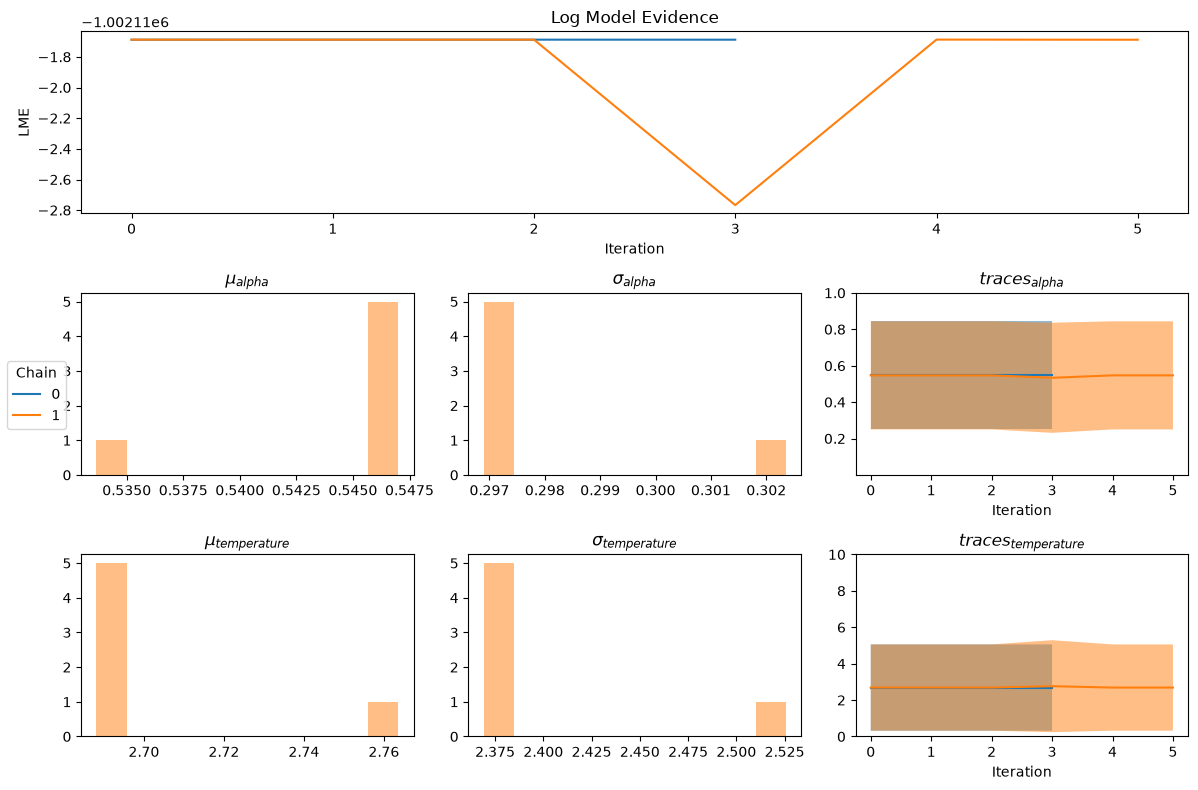

In [5]:
eb.diagnostics()

The estimated group distribution of the iteration with the highest LME is our empirical prior.

In [6]:
hyperparameters = eb.hyperparameters
best = hyperparameters.loc[hyperparameters.lme == hyperparameters.lme.max()]
best = best.drop_duplicates("parameter").set_index("parameter")[["mean", "sd"]]
best["true mean"] = [0.6, 2]
best["true sd"] = [0.2, 1]
best.round(2)

,mean,sd,true mean,true sd
parameter,,,,
alpha,0.55,0.30,0.6,0.2
temperature,2.69,2.37,2.0,1.0


The participant-level estimates of every iteration are stored in `eb.fit`.
We take the estimates of the same iteration and chain.

In [7]:
best_row = hyperparameters.loc[hyperparameters.lme.idxmax()]
empirical_bayes = (
    eb.fit[(eb.fit.chain == best_row.chain) & (eb.fit.iteration == best_row.iteration)]
    .sort_values("ppt")
    .reset_index(drop=True)
)
empirical_bayes[["alpha", "temperature"]].describe()

,alpha,temperature
count,50.000000,50.000000
mean,0.547013,2.688099
std,0.247382,1.362774
min,0.017481,0.567998
25%,0.406963,1.576051
50%,0.579247,2.456307
75%,0.745620,3.453586
max,1.000000,5.687499


## Comparing the estimates

We compare both sets of estimates with the true parameters.

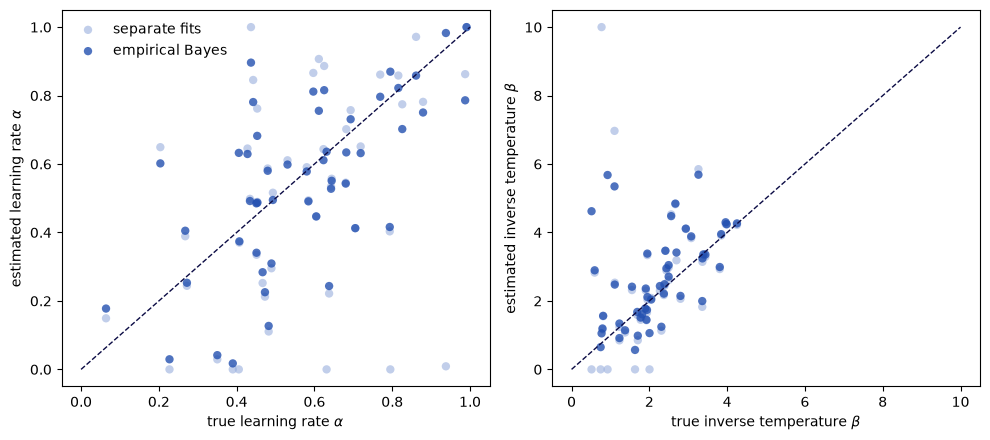

In [8]:
labels = {"alpha": r"learning rate $\alpha$", "temperature": r"inverse temperature $\beta$"}
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, name in zip(axes, labels):
    true = true_parameters[name]
    ax.scatter(true, maximum_likelihood[name], alpha=0.6, color="#98aedd", edgecolor="none", label="separate fits")
    ax.scatter(true, empirical_bayes[name], alpha=0.8, color="#2350b0", edgecolor="none", label="empirical Bayes")
    limits = [0, 1] if name == "alpha" else [0, 10]
    ax.plot(limits, limits, color="#0c0c45", linestyle="--", linewidth=1)
    ax.set_xlabel(f"true {labels[name]}")
    ax.set_ylabel(f"estimated {labels[name]}")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

In [9]:
errors = pd.DataFrame(
    {
        method: {
            name: np.mean(np.abs(estimates[name].to_numpy() - true_parameters[name].to_numpy()))
            for name in labels
        }
        for method, estimates in {"separate fits": maximum_likelihood, "empirical Bayes": empirical_bayes}.items()
    }
)
errors.index.name = "mean absolute error"
errors.round(3)

,separate fits,empirical Bayes
mean absolute error,,
alpha,0.213,0.149
temperature,0.969,0.854


The separate fits scatter more widely, and several end up at the bounds of the parameters (a learning rate of 0 or 1, or an inverse temperature of 0), because the choices of a single participant carry little information about the parameters when the inverse temperature is low.
Empirical Bayes pulls these estimates towards the group distribution, which reduces the error of the estimates, at the cost of shrinking genuine differences between participants a little.

## Summary and next steps

You estimated the group distribution of the parameters with empirical Bayes, checked that the algorithm converged, and showed with simulated data that the hierarchical estimates are closer to the true parameters than separate fits.

Empirical Bayes gives point estimates of the group distribution.
Variational Bayes goes a step further, and also estimates the uncertainty of the group distribution itself: see [5. Hierarchical estimation II: variational Bayes](hierarchical-variational-bayes.ipynb).

## References

Gershman, S. J. (2016). Empirical priors for reinforcement learning models. *Journal of Mathematical Psychology*, 71, 1–6. https://doi.org/10.1016/j.jmp.2016.01.006